# Método de Integração Numérica: Regra de Simpson 1/3

Este notebook implementa a Regra de Simpson 1/3 Composta para aproximar a integral definida de uma função de uma variável. O objetivo é analisar o comportamento do erro empírico à medida que aumentamos o número de subintervalos.

## 1. Importação de Bibliotecas e Definição da Função
Começamos importando a biblioteca `numpy` e definindo a função matemática $f(x) = e^x$ que será integrada.


In [1]:
import numpy as np

In [2]:
def definir_h (a, b, n):
    return (b-a)/n

def f(x):
    return np.exp(x)

## 2. Implementação do Algoritmo de Simpson
Abaixo criamos a função principal que calcula os pontos coordenados $x_i$, aplica os pesos correspondentes da Regra de Simpson ($1$ para as pontas, $4$ para índices ímpares e $2$ para índices pares) e calcula o erro absoluto em relação ao valor analítico (exato) da integral.


In [3]:
def calcular_simpson(a, b, n):
    h = definir_h(a, b, n)
    
    intervalos = []
    for i in range(0, n + 1):
        x = a + i * h
        intervalos.append(x)

    soma_impares = 0
    soma_pares = 0

    for i in range(1, n, 2):
        soma_impares += f(intervalos[i])

    for i in range(2, n, 2):
        soma_pares += f(intervalos[i])

    integral_aproximada = (h / 3) * (f(intervalos[0]) + 4 * soma_impares + 2 * soma_pares + f(intervalos[n]))
    
    valor_exato = np.exp(b) - np.exp(a)
    erro = abs(valor_exato - integral_aproximada)
    
    # Retorna os resultados organizados para usarmos onde quiser
    return h, intervalos, integral_aproximada, valor_exato, erro

## 3. Definição dos Parâmetros de Entrada
Definimos os limites de integração $[a, b] = [0, 1]$ e a lista com as diferentes quantidades de subintervalos ($n$) de teste. Como pré-requisito do método, todos os valores de $n$ precisam ser obrigatoriamente pares.

In [4]:
a = 0
b = 1

In [5]:
quant_subintervalos = [2, 4, 6, 8, 10, 20, 50, 100]

## 4. Execução dos Testes e Análise de Convergência
Executamos o loop iterando sobre a lista de subintervalos para avaliar os resultados e exibir o decaimento do erro empírico.


In [6]:
for n in quant_subintervalos:
    # Chama a função passando os parâmetros atuais
    h, intervalos, integral_aprox, valor_exato, erro = calcular_simpson(a, b, n)
    
    print(f"Número de subintervalos (n): {n}")
    print(f"Tamanho dos subintervalos (h): {h:.4f}")
    print(f"Intervalos utilizados: {[round(x, 4) for x in intervalos]}")
    print(f"Valor aproximado da integral: {integral_aprox:.10f}")
    print(f"Valor exato (e^b - e^a): {valor_exato:.10f}")
    # Formatado com :.4e para mostrar em notação científica organizada ou :.10f para decimal puro
    print(f"Erro empírico: {erro:.4e}\n")
    print("-" * 50)

Número de subintervalos (n): 2
Tamanho dos subintervalos (h): 0.5000
Intervalos utilizados: [0.0, 0.5, 1.0]
Valor aproximado da integral: 1.7188611519
Valor exato (e^b - e^a): 1.7182818285
Erro empírico: 5.7932e-04

--------------------------------------------------
Número de subintervalos (n): 4
Tamanho dos subintervalos (h): 0.2500
Intervalos utilizados: [0.0, 0.25, 0.5, 0.75, 1.0]
Valor aproximado da integral: 1.7183188419
Valor exato (e^b - e^a): 1.7182818285
Erro empírico: 3.7013e-05

--------------------------------------------------
Número de subintervalos (n): 6
Tamanho dos subintervalos (h): 0.1667
Intervalos utilizados: [0.0, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]
Valor aproximado da integral: 1.7182891699
Valor exato (e^b - e^a): 1.7182818285
Erro empírico: 7.3415e-06

--------------------------------------------------
Número de subintervalos (n): 8
Tamanho dos subintervalos (h): 0.1250
Intervalos utilizados: [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]
Valor a

## 5. Tabela de Resultados e Análise Gráfica da Convergência

Organizamos os resultados em uma tabela e construímos um gráfico em escala log-log do erro empírico em função do número de subintervalos $n$. Como o erro se comporta como $O(h^4)$ e $h = (b-a)/n$, nessa escala espera-se uma reta de inclinação $-4$, confirmando visualmente a ordem de convergência teórica do método.

,n,h,Valor aproximado,Erro empírico
0,2,0.500000,1.718861,5.793234e-04
1,4,0.250000,1.718319,3.701346e-05
2,6,0.166667,1.718289,7.341462e-06
3,8,0.125000,1.718284,2.326241e-06
4,10,0.100000,1.718283,9.534658e-07
5,20,0.050000,1.718282,5.964481e-08
6,50,0.020000,1.718282,1.527289e-09
7,100,0.010000,1.718282,9.545920e-11


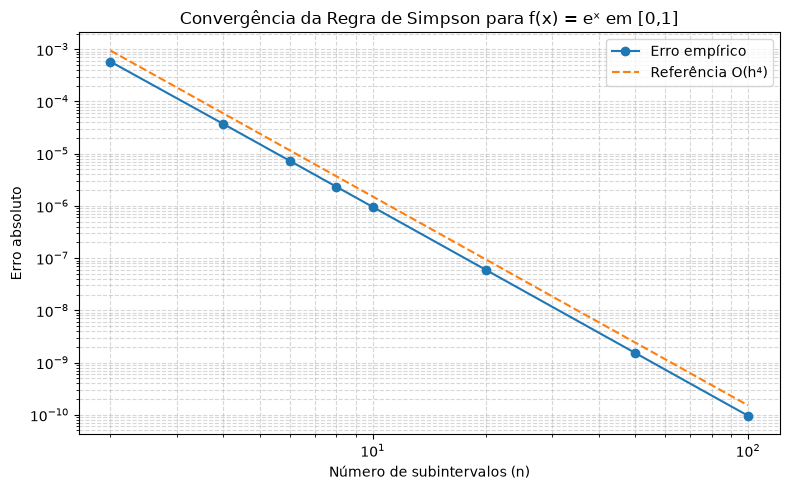

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

resultados = []
for n in quant_subintervalos:
    h, intervalos, integral_aprox, valor_exato, erro = calcular_simpson(a, b, n)
    resultados.append({"n": n, "h": h, "Valor aproximado": integral_aprox, "Erro empírico": erro})

tabela = pd.DataFrame(resultados)
display(tabela)

plt.figure(figsize=(8, 5))
plt.loglog(tabela["n"], tabela["Erro empírico"], marker="o", label="Erro empírico")
n_teorico = np.array([2, 100])
h_teorico = (b - a) / n_teorico
erro_teorico = ((b - a) / 180) * np.exp(1) * h_teorico**4
plt.loglog(n_teorico, erro_teorico, "--", label="Referência O(h⁴)")
plt.xlabel("Número de subintervalos (n)")
plt.ylabel("Erro absoluto")
plt.title("Convergência da Regra de Simpson para f(x) = eˣ em [0,1]")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Análise de Convergência
A Regra de Simpson Composta possui uma ordem de convergência teórica de $O(h^4)$. Observando as saídas obtidas:
* Quando $n$ dobra de **2 para 4** (o que significa reduzir $h$ pela metade), o erro cai de $5.79 \times 10^{-4}$ para $3.70 \times 10^{-5}$ (uma redução de aproximadamente **16 vezes**, condizente com $2^4 = 16$).
* Ao atingirmos $n = 100$, o erro empírico chega à escala infinitesimal de $10^{-11}$, provando a excelente estabilidade e alta precisão do método numérico implementado.
